<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/kmeans_km.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [1]:
!pip install plotly
!pip install tabulate
!pip install pandas openpyxl

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Clustering
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.cluster import KMeans


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Importing Data**

In [3]:
# Reading data

url = "https://raw.githubusercontent.com/kwanda2426/projects/main/airpoll_spreadsheet.xlsx"

In [4]:
df = pd.read_excel(url)


In [5]:
# Showing first 5 lines of data
df.head()


,SO2,NO2,O3,PM2.5,PM10
0,12.066771,26.209577,50.274385,30.133367,49.601856
1,9.960118,26.414410,50.725530,39.431072,63.532406
2,13.042188,28.175000,59.656341,30.048178,51.604358
3,14.110423,30.427946,45.042525,35.744039,59.892717
4,16.469369,25.970691,46.352582,22.802231,39.986833


In [6]:
#data columns
df.columns

Index(['SO2', 'NO2', 'O3', 'PM2.5', 'PM10'], dtype='object')

In [7]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following columns:')
for i in df.columns:
  print(i)

Data has 3347 rows and 5 Columns

Data has the following columns:
SO2
NO2
O3
PM2.5
PM10


### Data Type of Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SO2     3347 non-null   float64
 1   NO2     3347 non-null   float64
 2   O3      3347 non-null   float64
 3   PM2.5   3347 non-null   float64
 4   PM10    3347 non-null   float64
dtypes: float64(5)
memory usage: 130.9 KB


Data set has no missing values.

## Describing the variables

In [9]:
#describing numerical columns
df.describe()

,SO2,NO2,O3,PM2.5,PM10
count,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000
mean,15.457743,30.233894,49.046178,30.840341,53.068965
std,7.958836,9.840362,13.678701,10.881794,19.495417
min,2.440214,5.313647,14.307370,7.247189,12.460333
25%,9.822467,23.342326,38.955383,23.265236,39.293278
50%,13.668863,28.622035,47.986737,29.131225,49.776500
75%,19.211052,35.268649,57.857050,36.256992,63.601911
max,63.565143,80.808551,103.912130,80.611000,131.746833


# **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.


**Correlation**

This is meant to discover :

    Relationship between features and target variable.
    Multicollinearity - where features are highly correlated to each other. This guides whether to combine features or not as this means that features carry the same information.
    Most informative features. This helps to (simplify the model, reduce noise and improve predictive accuracy) by focusing on informative features only.
    Patterns such as if one feature increases, so does another OR One decreases , the other increases.
    +1 shows a strong positive correlation and -1 shows a strong negative correlation.



In [11]:


# Compute correlation matrix
df_corr = df.copy()
corr_matrix = df_corr.corr(numeric_only=True)

# Create heatmap
fig = px.imshow(
    corr_matrix,
    text_auto = True,
    color_continuous_scale = 'RdBu',
    zmin = -1, zmax = 1,
    title = 'Feature Correlation Heatmap'
)

fig.update_layout(
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()




## **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

In [12]:
df.head()

,SO2,NO2,O3,PM2.5,PM10
0,12.066771,26.209577,50.274385,30.133367,49.601856
1,9.960118,26.414410,50.725530,39.431072,63.532406
2,13.042188,28.175000,59.656341,30.048178,51.604358
3,14.110423,30.427946,45.042525,35.744039,59.892717
4,16.469369,25.970691,46.352582,22.802231,39.986833


###**Drug Distribution**

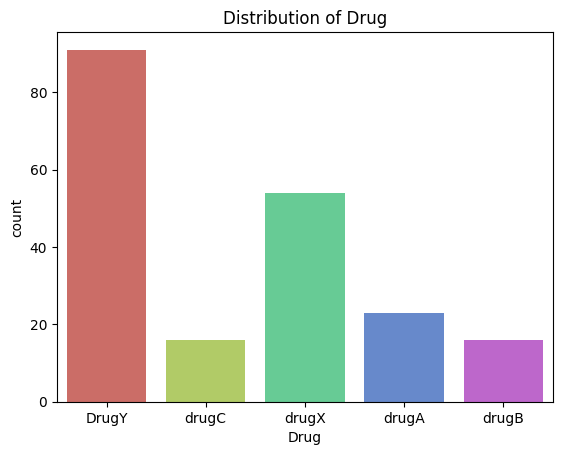

In [ ]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'Drug', data = df_1, palette = "hls")
plt.title("Distribution of Drug");

- DrugY and DrugX are the two that are represented the most in this dataset.

###**Gender(sex) Distribution**

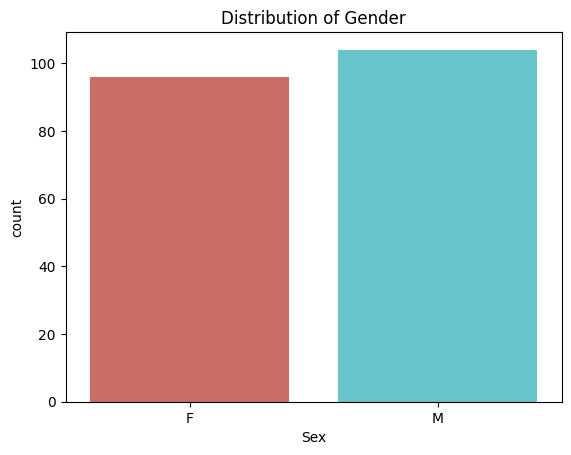

In [ ]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'Sex', data = df_1, palette = "hls")
plt.title("Distribution of Gender");

These two groups are fairly equally represented, meaning gender is unlikely to be a strong predictor of drug type.

###**Age Distribution**

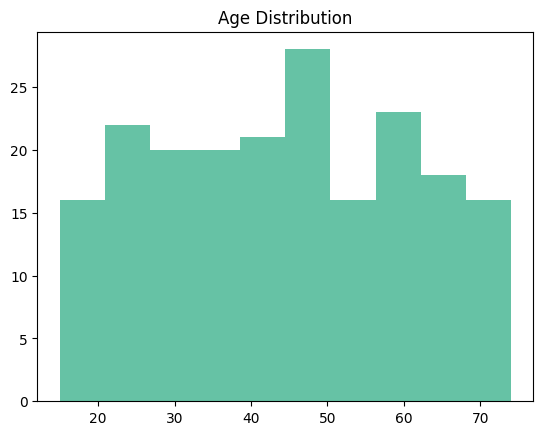

In [ ]:
plt.hist(df['Age'],color='#66C2A5')
plt.title("Age Distribution")
plt.show()

- The data ranges between 15 and 74 years. There's a peak between the age of 45 and 50.
- This indicates that middle-aged patients are more represented and might influence drug prescription patterns.

###**Blood Pressure(BP) Distribution**

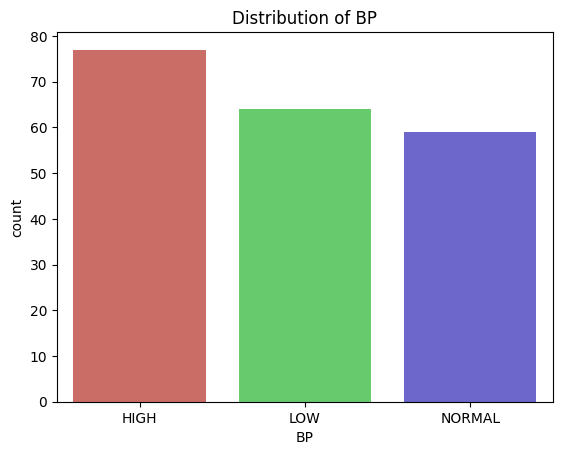

In [ ]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'BP', data = df_1, palette = "hls")
plt.title("Distribution of BP");

All categories are fairly represented though HIGH is slightly more than the others.

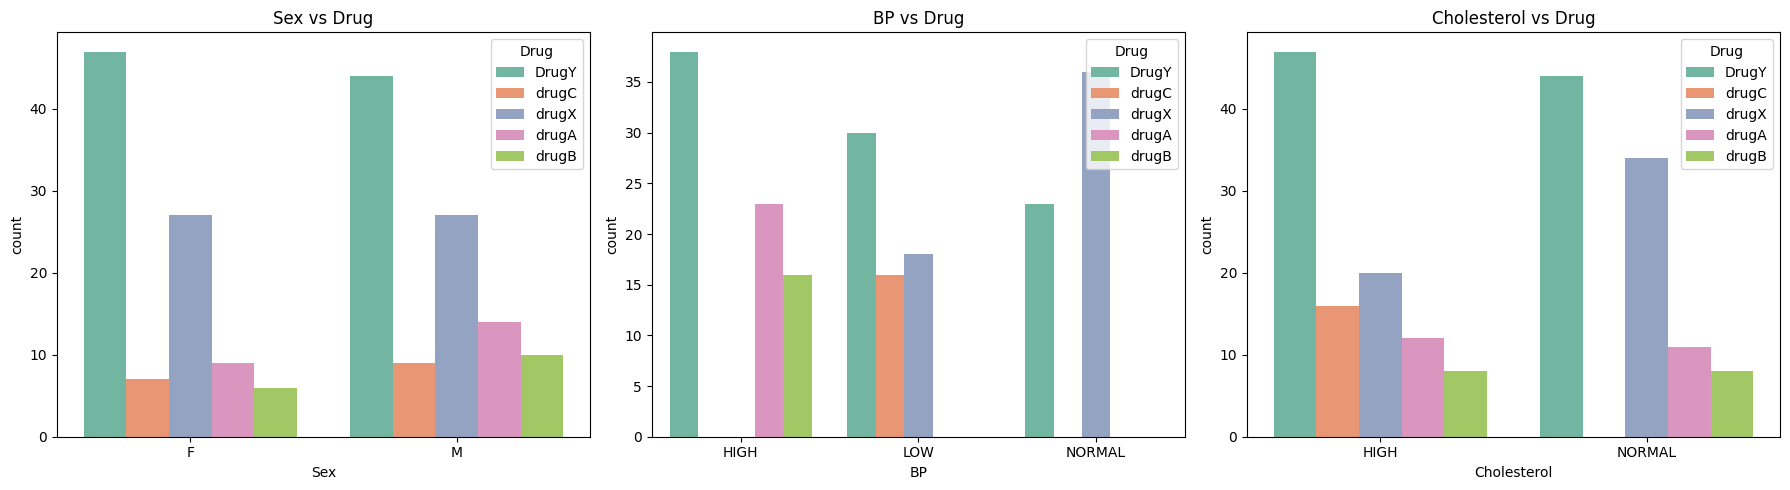

In [ ]:
# Drug vs Sex, BP and Cholesterol

df_1 = df.copy()
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x = 'Sex', hue = 'Drug', data = df_1, palette = 'Set2')
plt.title('Sex vs Drug')

plt.subplot(1, 3, 2)
sns.countplot(x = 'BP', hue = 'Drug', data = df_1, palette = 'Set2')
plt.title('BP vs Drug')

plt.subplot(1, 3, 3)
sns.countplot(x = 'Cholesterol', hue = 'Drug', data = df_1, palette = 'Set2')
plt.title('Cholesterol vs Drug')

plt.tight_layout()
plt.show()

- Overall, DrugY is the one that's ministered the most Across different Matrics.

- Sex: The shape is fairly similar in both genders; limited predictive power.
- BP: Strong impact; High BP strongly linked to DrugY.
- Cholesterol: Highly influential; high cholesterol patients often prescribed DrugY/DrugX. Normal patients do not get DrugC.

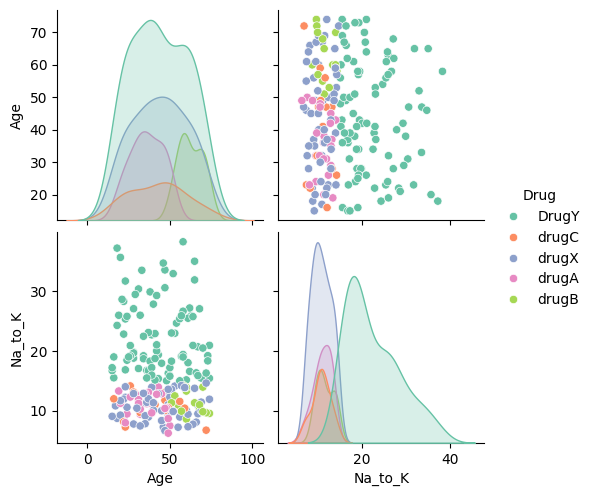

In [ ]:
df_1 = df.copy()
sns.pairplot(df_1, vars = ['Age', 'Na_to_K'], hue = 'Drug', diag_kind = 'kde', palette = 'Set2')


###**Key Take Aways**

- Age and Na_to_K ratio are the most important features for distinguishing drug types.
- DrugY is the most prescribed drug, strongly associated with high Na_to_K values and high blood pressure.
- Gender is not a strong predictor due to the balanced male–female distribution.
- Cholesterol and BP have moderate impact, but when combined with Age and Na_to_K, they enhance model performance.
- The dataset suffers from class imbalance (DrugY and DrugX dominate). This must be dealt with in feature engineering.
- Na_to_K is the “golden feature”: it is the strongest indicator for drug classification and should be central in any automated prescription system.

# **Model Building and Testing**

# **Model Evaluation**

**Classification Evaluation Metrics**

In [ ]:
#Model evaluation
from sklearn.metrics import mean_squared_error

metrics = {
    'Metric': ['Accuracy', 'Recall','Precision'],
    'Training': [accuracy_score(y_train, y_pred_tr), precision_score(y_train, y_pred_tr, average = 'weighted'),recall_score(y_train, y_pred_tr,average = 'weighted')],
    'Testing data': [accuracy_score(y_test, y_pred_te),precision_score(y_test, y_pred_te,average = 'weighted'),recall_score(y_test, y_pred_te,average = 'weighted')
    ]
}
# Create the DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(metrics_df, headers = 'keys', tablefmt = 'pretty'))

+---+-----------+----------+--------------+
|   |  Metric   | Training | Testing data |
+---+-----------+----------+--------------+
| 0 | Accuracy  |   1.0    |     1.0      |
| 1 |  Recall   |   1.0    |     1.0      |
| 2 | Precision |   1.0    |     1.0      |
+---+-----------+----------+--------------+
